# Tutorial: Calibrating Systematic Poking Material Parameters from Reaction Forces

**Goal**: fit Systematic Poking material parameters from a set of static
reaction-force curves so that the fitted material's reactions match a
Neo-Hookean target -- this time with a differentiable equilibrium layer.

This notebook implements the reaction-force calibration entirely with
PyTorch: the physics, mesh, and load cases follow the experiment exactly,
but the equilibrium solve is wrapped in
`pypgo.fem.torch.StaticEquilibriumLayer`. The layer's backward pass
implements the implicit-function-theorem adjoint internally, so the gradient
of every reaction with respect to the material parameters comes from autograd
instead of a hand-written formula.

The material parameters are optimized with a standard PyTorch optimizer
(`torch.optim.Adam`) on a scalar loss: normalized reaction mismatch plus a
smoothness penalty on the spline parameters.

## Outline

1. Build a 2×2×2 hexahedral grid;
2. Construct the elastic energy operator (material definition / binding);
3. Define load cases and wrap each one in a differentiable equilibrium layer;
4. Generate "ground truth" reactions with the target material;
5. Define a scalar loss and let autograd compute its gradient;
6. Optimize the material parameters with a PyTorch optimizer;
7. Results and visualization.

## 0. Setup

The cell below adds the repository root to `sys.path` so `pypgo` is importable
from any directory, and sets the C++ backend's log level to `off` so spdlog
does not flood the output. PyTorch is an optional dependency
(`pip install pypgo[torch]`); the torch layer lives in `pypgo.fem.torch` and is
imported lazily.

In [8]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pypgo").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import torch

import pypgo as pgo
import pypgo.fem as pf
import pypgo.solver as ps
from pypgo.fem.torch import StaticEquilibriumLayer

# The C++ backend logs through spdlog to stdout; silence it for this notebook.
# Restore at any time with pgo.set_log_level("info").
pgo.set_log_level("off")

## 1. Experiment configuration and mesh

All experimental constants live at the top. The mesh is a unit cube split
into `GRID_SIZE^3` hexahedra (8 corners each) -- tiny, but enough to produce
meaningful reaction-force curves.

In [9]:
TARGET_E, TARGET_NU = 2.0e5, 0.35   # target Neo-Hookean material
INIT_E, INIT_NU = 1.2e5, 0.25       # starting guess for the fit
FORCE_SCALE = TARGET_E              # forces/parameters normalized by E
STATIC_TOL = 1.0e-6                 # equilibrium residual threshold
SMOOTHNESS = 1.0e-3                 # second-difference regularization weight
KNOT_COUNT = 17                     # stretch/volume knots (must be odd)
GRID_SIZE = 2                       # grid: divisions along each axis
SHEARS = (-0.8, -0.4, 0.4, 0.8)     # training shear magnitudes


def make_grid(n: int = GRID_SIZE):
    ids = np.arange((n + 1) ** 3).reshape((n + 1, n + 1, n + 1))
    vertices = np.array(
        [[i / n, j / n, k / n]
         for i in range(n + 1) for j in range(n + 1) for k in range(n + 1)],
        dtype=np.float64,
    )
    elements = np.array(
        [[ids[i, j, k], ids[i + 1, j, k], ids[i + 1, j + 1, k],
          ids[i, j + 1, k], ids[i, j, k + 1], ids[i + 1, j, k + 1],
          ids[i + 1, j + 1, k + 1], ids[i, j + 1, k + 1]]
         for i in range(n) for j in range(n) for k in range(n)],
        dtype=np.int64,
    )
    return vertices, elements


vertices, elements = make_grid()
print(f"vertices = {len(vertices)}   elements = {len(elements)}   "
      f"displacement dofs = {vertices.size}")

vertices = 27   elements = 8   displacement dofs = 81


## 2. Building the elastic energy operator

`pypgo`'s material system has two layers:

- **Fixed channels** (`MaterialBinding`): per-element constants such as E, nu;
- **Optimizable channels** (`MaterialState`): the values being fitted, e.g.
  Systematic Poking's f''(knot) values and lambda.

The `DeformationEnergyOperator` is immutable and owns the binding, so we build
it **once** per material and share it across all load cases. Each forward pass
of the torch layer binds a fresh `MaterialState` to the operator; no per-case
energy construction is needed. The target material (Neo-Hookean) has zero
optimizable channels; the fitted material (Systematic Poking) has `f''(knot)`
values plus lambda.

In [10]:
def fixed_channel_block(elastic, num_elements):
    """Element-major fixed channels for the MaterialBinding."""
    if elastic.name == "neo_hookean":
        return np.tile([TARGET_E, TARGET_NU], (num_elements, 1))
    if elastic.name == "systematic_poking":
        # Knot locations live in the definition; no per-element fixed channels
        return np.empty((num_elements, 0), dtype=np.float64)
    raise ValueError(f"unsupported fixed channels for {elastic.name}")


def make_operator(elastic):
    """Build a shared CubicLinear operator for one material definition."""
    volume = pgo.mesh.volume.VolumeMesh(
        pgo.mesh.CubicMeshData(*make_grid()),
        pgo.mesh.volume.ENuMaterial(E=TARGET_E, nu=TARGET_NU),
    )
    mesh = pf.SimulationMesh(volume)
    plastic = pf.VolumetricPlasticityDefinition(dofs=0)
    binding = pf.MaterialBinding(
        pf.ElasticMaterialBinding(
            elastic, mesh.num_elements,
            fixed_channel_block(elastic, mesh.num_elements)),
        pf.PlasticMaterialBinding(
            plastic, mesh.num_elements,
            np.empty((mesh.num_elements, 0), dtype=np.float64)),
    )
    return pf.DeformationEnergyOperator(
        mesh, binding,
        formulation=pf.CubicLinear(),
        options=pf.DeformationOptions(project_hessian_psd=False),
    )


knots = np.exp(np.linspace(np.log(0.5), np.log(2.0), KNOT_COUNT))
vol_knots = np.exp(np.linspace(-1.0, 1.0, KNOT_COUNT))
initial_params = np.concatenate([
    (INIT_E / (2 * (1 + INIT_NU))) * (1 + 1 / knots ** 2),
    [INIT_E * INIT_NU / ((1 + INIT_NU) * (1 - 2 * INIT_NU))],
])
systematic = pf.SystematicPokingDefinition(
    knots, KNOT_COUNT // 2, vol_knots, KNOT_COUNT // 2)

operator = make_operator(systematic)
target_operator = make_operator(pf.NeoHookeanDefinition())
print(f"systematic: {operator.num_dofs} dofs, "
      f"{operator.num_elastic_params} optimizable elastic channels/element")
print(f"neo-hookean: {target_operator.num_dofs} dofs, "
      f"{target_operator.num_elastic_params} optimizable elastic channels/element")

systematic: 81 dofs, 18 optimizable elastic channels/element
neo-hookean: 81 dofs, 0 optimizable elastic channels/element


## 3. Load cases and reactions

Each load case is a set of **displacement boundary conditions** plus a
**reaction readout**:

- Uniaxial: bottom y fixed, top y compressed to `stretch`; `confined` also
  locks the sides, `free` adds only three minimal rigid pins;
- Shear: bottom fully fixed, top x translated by `shear`.

The reaction is `reaction_selector @ gradient`, i.e. the total force on the
top face: once the equilibrium is solved, the gradient *is* the reaction
force.

In [11]:
from dataclasses import dataclass


@dataclass
class LoadCase:
    label: str
    protocol: str
    coordinate: float
    fixed_dofs: np.ndarray
    fixed_values: np.ndarray
    free_dofs: np.ndarray
    reaction_selector: np.ndarray
    initial_displacement: np.ndarray
    target: float = 0.0


def constraints_from_mapping(mapping, num_dofs):
    fixed_dofs = np.array(sorted(mapping), dtype=np.int64)
    fixed_values = np.array([mapping[int(d)] for d in fixed_dofs], dtype=np.float64)
    free_dofs = np.setdiff1d(np.arange(num_dofs, dtype=np.int64), fixed_dofs)
    return fixed_dofs, fixed_values, free_dofs


def free_uniaxial_pins(vertices, bottom):
    positions = vertices[bottom]
    centroid = positions.mean(axis=0)
    d2 = ((positions[:, 0] - centroid[0]) ** 2 +
          (positions[:, 2] - centroid[2]) ** 2)
    anchor = int(bottom[np.argmin(d2)])
    same_z = bottom[np.isclose(vertices[bottom, 2], vertices[anchor, 2])]
    candidates = same_z[same_z != anchor]
    if candidates.size == 0:
        candidates = bottom[bottom != anchor]
    rotation_pin = int(candidates[np.argmax(
        np.abs(vertices[candidates, 0] - vertices[anchor, 0]))])
    return anchor, rotation_pin


def _boundary_vertices(vertices):
    bottom = np.flatnonzero(np.isclose(vertices[:, 1], 0.0))
    top = np.flatnonzero(np.isclose(vertices[:, 1], 1.0))
    return bottom, top


def free_uniaxial_cases(vertices, stretches):
    """Bottom fixed in y; top compressed along y; three rigid pins on the bottom."""
    num_dofs = vertices.size
    bottom, top = _boundary_vertices(vertices)
    cases = []
    for stretch in stretches:
        mapping = {}
        for v in bottom:
            mapping[3 * int(v) + 1] = 0.0
        for v in top:
            mapping[3 * int(v) + 1] = stretch - 1.0
        anchor, rotation_pin = free_uniaxial_pins(vertices, bottom)
        mapping[3 * anchor] = 0.0
        mapping[3 * anchor + 2] = 0.0
        mapping[3 * rotation_pin + 2] = 0.0
        fixed_dofs, fixed_values, free_dofs = constraints_from_mapping(
            mapping, num_dofs)
        selector = np.zeros(num_dofs)
        selector[3 * top + 1] = 1.0
        initial = np.zeros(num_dofs)
        initial[1::3] = (stretch - 1.0) * vertices[:, 1]
        cases.append(LoadCase(
            label=f"free_uniaxial_{stretch:.3f}",
            protocol="free_uniaxial",
            coordinate=stretch,
            fixed_dofs=fixed_dofs, fixed_values=fixed_values,
            free_dofs=free_dofs, reaction_selector=selector,
            initial_displacement=initial))
    return cases


def confined_uniaxial_cases(vertices, stretches):
    """Bottom fixed in y; top compressed along y; all x/z DOFs pinned."""
    num_dofs = vertices.size
    bottom, top = _boundary_vertices(vertices)
    cases = []
    for stretch in stretches:
        mapping = {}
        for v in bottom:
            mapping[3 * int(v) + 1] = 0.0
        for v in top:
            mapping[3 * int(v) + 1] = stretch - 1.0
        for v in range(len(vertices)):
            mapping[3 * v] = 0.0
            mapping[3 * v + 2] = 0.0
        fixed_dofs, fixed_values, free_dofs = constraints_from_mapping(
            mapping, num_dofs)
        selector = np.zeros(num_dofs)
        selector[3 * top + 1] = 1.0
        initial = np.zeros(num_dofs)
        initial[1::3] = (stretch - 1.0) * vertices[:, 1]
        cases.append(LoadCase(
            label=f"confined_uniaxial_{stretch:.3f}",
            protocol="confined_uniaxial",
            coordinate=stretch,
            fixed_dofs=fixed_dofs, fixed_values=fixed_values,
            free_dofs=free_dofs, reaction_selector=selector,
            initial_displacement=initial))
    return cases


def simple_shear_cases(vertices, shears):
    """Bottom fully fixed; top translated along x by the shear amount."""
    num_dofs = vertices.size
    bottom, top = _boundary_vertices(vertices)
    cases = []
    for shear in shears:
        mapping = {}
        for v in bottom:
            for c in range(3):
                mapping[3 * int(v) + c] = 0.0
        for v in top:
            mapping[3 * int(v)] = shear
            mapping[3 * int(v) + 1] = 0.0
        fixed_dofs, fixed_values, free_dofs = constraints_from_mapping(
            mapping, num_dofs)
        selector = np.zeros(num_dofs)
        selector[3 * top] = 1.0
        initial = np.zeros(num_dofs)
        initial[0::3] = shear * vertices[:, 1]
        cases.append(LoadCase(
            label=f"simple_shear_{shear:+.3f}", protocol="simple_shear",
            coordinate=shear,
            fixed_dofs=fixed_dofs, fixed_values=fixed_values,
            free_dofs=free_dofs, reaction_selector=selector,
            initial_displacement=initial))
    return cases


def make_cases(vertices, knots):
    """Build the three protocol families explicitly and concatenate them."""
    stretches = [k for i, k in enumerate(knots) if i != len(knots) // 2]
    return (
        free_uniaxial_cases(vertices, stretches)
        + confined_uniaxial_cases(vertices, stretches)
        + simple_shear_cases(vertices, SHEARS)
    )

### Wrapping each load case in a differentiable equilibrium layer

`StaticEquilibriumLayer` is the torch bridge. It owns one load case's
immutable physics (shared operator, boundary conditions, inner Newton
optimizer, sparse-solver backend) and exposes the equilibrium solve as a
differentiable function:

- `forward(elastic_values, plastic_values)` solves the static equilibrium with
  the C++ Newton optimizer and returns the reaction
  `c^T grad E(u*)` (or `u*` itself if no selector is given);
- `backward` implements the implicit-function-theorem adjoint with the Hessian
  at the converged state and the operator's `material_vjp`, so Newton
  iterations are never unrolled into the autograd graph.

Inputs are element-major float64 CPU tensors of shape
`(num_elements, num_channels)`. Global parameters are broadcast by the caller
with `params.expand(num_elements, -1)`. The plastic argument is required and
uses shape `(num_elements, 0)` when the model has no plastic channels.

In [12]:
OPTIMIZER = ps.NewtonOptimizer(
    max_iterations=200,
    termination=ps.AbsoluteTermination(abs_tolerance=1.0e-10),
)

cases = make_cases(operator.vertex_rest_positions, knots)
layers = [
    StaticEquilibriumLayer(
        energy_operator=operator,
        fixed_dofs=case.fixed_dofs,
        fixed_values=case.fixed_values,
        reaction_selectors=case.reaction_selector,
        inner_optimizer=OPTIMIZER,
        sparse_backend=ps.EigenLDLT(),
        initial_displacement=case.initial_displacement,
        residual_tol=STATIC_TOL,
    )
    for case in cases
]

num_elements = operator.num_elements
plastic_empty = torch.empty((num_elements, 0), dtype=torch.float64)

# One probe reaction through the first layer.
probe_params = torch.as_tensor(
    np.broadcast_to(
        initial_params, (num_elements, initial_params.size)).copy(),
    dtype=torch.float64)
probe = layers[0](probe_params, plastic_empty)
print(f"case: {cases[0].label}")
print(f"reaction / E = {probe.item() / FORCE_SCALE:.6f}")

case: free_uniaxial_0.500
reaction / E = -0.542338


### Visualizing the solved configurations

Before fitting, look at one solved configuration per protocol.  The
layer solves the equilibrium with the initial material and keeps the
converged displacement (`layer._last_displacement`); we rebuild the
deformed surface mesh directly and render it with `pgo.visualize` --
no intermediate OBJ files.  PyVista is an optional dependency: the
cell falls back to a message when it is not installed.

In [13]:
def deformed_surface(energy_operator, displacement):
    """Surface TriMeshData of a deformed configuration."""
    deformed = (
        energy_operator.vertex_rest_positions
        + displacement.reshape(-1, 3))
    volume = pgo.mesh.volume.VolumeMesh(
        pgo.mesh.CubicMeshData(deformed, elements),
        pgo.mesh.volume.ENuMaterial(),
    )
    return volume.extract_surface_mesh()


try:
    pgo.visualize  # lazy import; requires pyvista
    HAS_VIZ = True
except Exception:
    HAS_VIZ = False

if HAS_VIZ:
    rest_volume = pgo.mesh.volume.VolumeMesh(
        pgo.mesh.CubicMeshData(vertices, elements),
        pgo.mesh.volume.ENuMaterial(),
    )
    rest_surface = rest_volume.extract_surface_mesh()
    seen = {}
    for layer, case in zip(layers, cases):
        if case.protocol not in seen:
            seen[case.protocol] = (layer, case)
    for protocol, color in (
            ("simple_shear", "lightsteelblue"),
            ("free_uniaxial", "lightcoral"),
            ("confined_uniaxial", "lightgreen")):
        layer, case = seen[protocol]
        layer(probe_params, plastic_empty)
        deformed = deformed_surface(
            operator, layer._last_displacement)
        pgo.visualize.plot_surface(
            [rest_surface, deformed],
            titles=["rest",
                    f"{case.protocol} ({case.coordinate:+.3f})"],
            colors=["lightgray", color],
            window_size=(800, 420),
            backend="jupyter",
        )
else:
    print("pyvista is not installed; skipping 3D visualization")


Widget(value='<iframe src="http://localhost:60772/index.html?ui=P_0x16511ce30_3&reconnect=auto" class="pyvista…

Widget(value='<iframe src="http://localhost:60772/index.html?ui=P_0x13541fdd0_4&reconnect=auto" class="pyvista…

Widget(value='<iframe src="http://localhost:60772/index.html?ui=P_0x16688c170_5&reconnect=auto" class="pyvista…

## 4. Generating the target data

The target Neo-Hookean material has zero optimizable channels, so its layer
input is `(num_elements, 0)`. We solve every load case with the target
operator and store the resulting reactions as `targets` -- our training
labels.

In [14]:
target_layers = [
    StaticEquilibriumLayer(
        energy_operator=target_operator,
        fixed_dofs=case.fixed_dofs,
        fixed_values=case.fixed_values,
        reaction_selectors=case.reaction_selector,
        inner_optimizer=OPTIMIZER,
        sparse_backend=ps.EigenLDLT(),
        initial_displacement=case.initial_displacement,
        residual_tol=STATIC_TOL,
    )
    for case in cases
]

target_empty = torch.empty((num_elements, 0), dtype=torch.float64)
targets = torch.stack([
    layer(target_empty, target_empty) for layer in target_layers])

# Backfill the per-case labels so the plotting section can read them directly.
for case, value in zip(cases, targets):
    case.target = float(value.detach())

print(f"{len(cases)} training cases; first 6 normalized reactions:")
print(np.round((targets[:6] / FORCE_SCALE).numpy(), 5))

36 training cases; first 6 normalized reactions:
[-0.97624 -0.80875 -0.65835 -0.52273 -0.3998  -0.2877 ]


## 5. Loss and gradient via autograd

Instead of building residual vectors and Jacobian matrices by hand, we treat
the whole experiment as one differentiable loss: the normalized reaction
mismatch plus a smoothness penalty on `f''(knot)`.

`loss.backward()` propagates through every `StaticEquilibriumLayer`. The
layer's backward is the implicit-function-theorem adjoint

$$K_{ff}^T \lambda = (K^T c)_f, \qquad
  \frac{dE}{d\theta} = \left(c^T E_{ue} - \lambda^T E_{ue,f}\right) p,$$

with $K = \frac{\partial^2 E}{\partial u^2}$ and $c$ the reaction selector,
so Newton iterations are never unrolled into the autograd graph. No explicit
residual/Jacobian bookkeeping is needed in user code.

In [15]:
def reactions(theta):
    """Stack the differentiable reaction of every load case."""
    params = FORCE_SCALE * torch.exp(theta)
    values = params.expand(num_elements, -1)
    return torch.stack([layer(values, plastic_empty) for layer in layers])


def smoothness_penalty(theta, weight=SMOOTHNESS):
    """Second-difference penalty on f''(knot); lambda (last param) excluded."""
    if weight <= 0.0:
        return torch.tensor(0.0, dtype=theta.dtype)
    f_dd = theta[:-1]
    diff2 = f_dd[2:] - 2.0 * f_dd[1:-1] + f_dd[:-2]
    return weight * torch.mean(diff2 ** 2)


def loss_and_rmse(theta):
    """Total loss and training RMSE from the normalized reaction mismatch."""
    residual = (reactions(theta) - targets) / FORCE_SCALE
    data_loss = torch.mean(residual ** 2)
    return data_loss + smoothness_penalty(theta), torch.sqrt(data_loss)


theta0 = torch.tensor(
    np.log(initial_params / FORCE_SCALE), dtype=torch.float64)

_, initial_rmse = loss_and_rmse(theta0)
initial_rmse = float(initial_rmse)
print(f"initial RMSE = {initial_rmse:.6f}")

initial RMSE = 0.341117


## 6. Optimizing material parameters with a PyTorch optimizer

`theta = log(p / E_0)` keeps the physical parameters positive. The training
loop is a standard deep-learning building block: zero the gradients, compute
the scalar loss, call `loss.backward()`, and let `torch.optim.Adam` take a
step. The gradient carries exactly the same information as the reaction
Jacobian used by Gauss-Newton, but PyTorch computes it for us.

In [16]:
theta = torch.tensor(
    np.log(initial_params / FORCE_SCALE), dtype=torch.float64,
    requires_grad=True)
optimizer = torch.optim.Adam([theta], lr=3.0e-2)

fit_history = []
for iteration in range(500):
    optimizer.zero_grad()
    loss, train_rmse = loss_and_rmse(theta)
    loss.backward()
    optimizer.step()

    fit_history.append({
        "iteration": iteration,
        "loss": float(loss.detach()),
        "train_rmse": float(train_rmse.detach()),
    })
    if iteration % 20 == 0 or iteration == 499:
        print(f"iter {iteration:3d}  loss={float(loss.detach()):.3e}  "
              f"train_rmse={float(train_rmse.detach()):.3e}")
    if float(train_rmse.detach()) < 1.0e-8:
        print("converged: train RMSE below tolerance")
        break

iter   0  loss=1.164e-01  train_rmse=3.411e-01
iter  20  loss=1.760e-02  train_rmse=1.327e-01
iter  40  loss=5.911e-03  train_rmse=7.686e-02
iter  60  loss=1.482e-03  train_rmse=3.837e-02
iter  80  loss=3.320e-04  train_rmse=1.779e-02
iter 100  loss=1.513e-04  train_rmse=1.167e-02
iter 120  loss=9.223e-05  train_rmse=8.932e-03
iter 140  loss=5.964e-05  train_rmse=7.099e-03
iter 160  loss=3.943e-05  train_rmse=5.727e-03
iter 180  loss=2.566e-05  train_rmse=4.587e-03
iter 200  loss=1.640e-05  train_rmse=3.643e-03
iter 220  loss=1.031e-05  train_rmse=2.870e-03
iter 240  loss=6.382e-06  train_rmse=2.246e-03
iter 260  loss=3.910e-06  train_rmse=1.747e-03
iter 280  loss=2.381e-06  train_rmse=1.354e-03
iter 300  loss=1.451e-06  train_rmse=1.049e-03
iter 320  loss=8.937e-07  train_rmse=8.159e-04
iter 340  loss=5.644e-07  train_rmse=6.408e-04
iter 360  loss=3.718e-07  train_rmse=5.126e-04
iter 380  loss=2.600e-07  train_rmse=4.215e-04
iter 400  loss=1.955e-07  train_rmse=3.592e-04
iter 420  los

## 7. Results and visualization

After the fit we check two things: how much the training RMSE dropped, and
how close the fitted f''/lambda values are to the closed-form Neo-Hookean
reference. Then we plot the reaction curves for the initial guess, the fitted
material, and the target, together with the optimization loss history.

In [17]:
fitted = FORCE_SCALE * torch.exp(theta.detach()).numpy()
mu, lam = (TARGET_E / (2 * (1 + TARGET_NU)),
           TARGET_E * TARGET_NU / ((1 + TARGET_NU) * (1 - 2 * TARGET_NU)))
reference = np.concatenate([mu * (1 + 1 / knots ** 2), [lam]])

_, final_rmse = loss_and_rmse(theta.detach())
print(f"train RMSE: initial={initial_rmse:.6f}  "
      f"fitted={float(final_rmse):.6e}")
print(f"{'parameter':10s} {'fitted':>12s} {'reference':>12s}")
for i, name in enumerate([f"f_dd_{i}" for i in range(KNOT_COUNT)] + ["lambda"]):
    print(f"{name:10s} {fitted[i]:12.1f} {reference[i]:12.1f}")

train RMSE: initial=0.341117  fitted=2.618219e-04
parameter        fitted    reference
f_dd_0         369134.5     370370.4
f_dd_1         322877.8     323228.6
f_dd_2         283293.7     283587.2
f_dd_3         249964.0     250252.9
f_dd_4         221892.3     222222.2
f_dd_5         198549.5     198651.3
f_dd_6         178919.2     178830.6
f_dd_7         161920.8     162163.5
f_dd_8         147502.8     148148.1
f_dd_9         135699.5     136362.7
f_dd_10        126177.9     126452.4
f_dd_11        118135.7     118118.8
f_dd_12        111018.6     111111.1
f_dd_13        104976.5     105218.4
f_dd_14        100033.1     100263.2
f_dd_15         95905.9      96096.4
f_dd_16         92155.7      92592.6
lambda         170506.8     172839.5


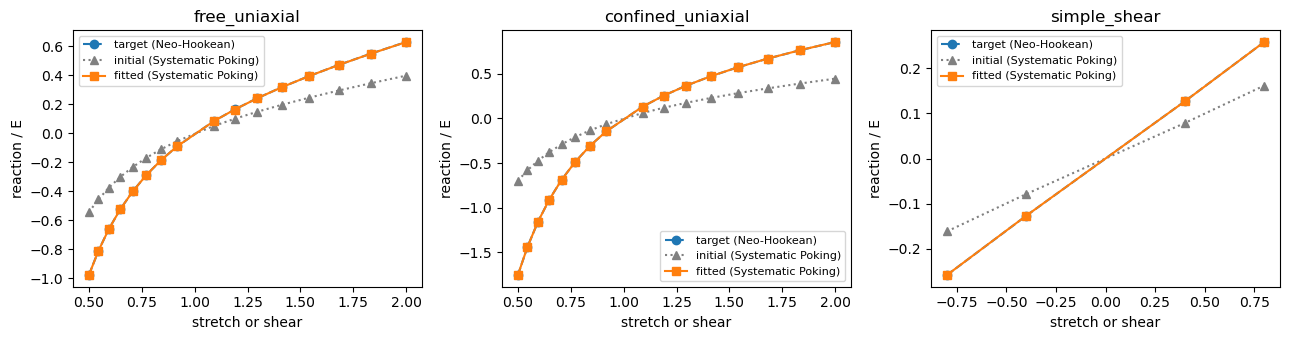

In [18]:
predicted = reactions(theta).detach().numpy()
initial_predicted = reactions(
    torch.tensor(np.log(initial_params / FORCE_SCALE), dtype=torch.float64)
).detach().numpy()

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception:
    HAS_MPL = False

if HAS_MPL:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
    for ax, protocol in zip(
            axes, ("free_uniaxial", "confined_uniaxial", "simple_shear")):
        sel = np.array([i for i, c in enumerate(cases) if c.protocol == protocol])
        order = np.argsort([cases[i].coordinate for i in sel])
        sel = sel[order]
        x_plot = [cases[i].coordinate for i in sel]
        ax.plot(x_plot, [cases[i].target / FORCE_SCALE for i in sel],
                "o--", label="target (Neo-Hookean)")
        ax.plot(x_plot, [initial_predicted[i] / FORCE_SCALE for i in sel],
                "^:", color="gray", label="initial (Systematic Poking)")
        ax.plot(x_plot, [predicted[i] / FORCE_SCALE for i in sel],
                "s-", label="fitted (Systematic Poking)")
        ax.set_title(protocol)
        ax.set_xlabel("stretch or shear")
        ax.set_ylabel("reaction / E")
        ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()
else:
    print("matplotlib is not installed; skipping the plot")

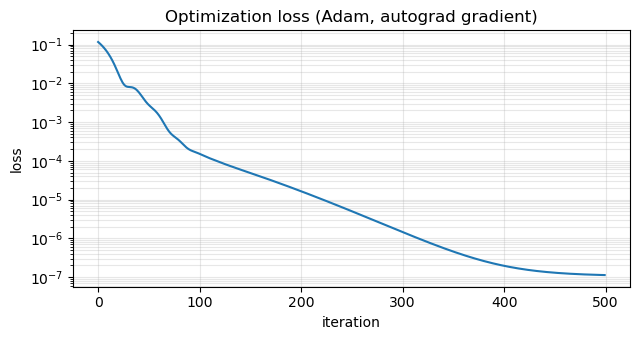

In [21]:
try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception:
    HAS_MPL = False

if HAS_MPL:
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    ax.semilogy(
        [h["iteration"] for h in fit_history],
        [h["loss"] for h in fit_history],
        "-",
    )
    ax.set_xlabel("iteration")
    ax.set_ylabel("loss")
    ax.set_title("Optimization loss (Adam, autograd gradient)")
    ax.grid(True, which="both", alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print("matplotlib is not installed; skipping the loss plot")